## Task description:

a. Create a query that returns a table containing the following columns: order ID, product name, product category, and product price.

b. Load the dataset into Python – in case of any issues, a detailed instruction is available here:
https://github.com/kingagla/easy_example/tree/SQL_connection/SQL

c. Describe the variables present in the dataset.

d. Test whether products in individual categories are sold equally often.

### 1. Libraries

In [2]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from scipy.stats import skew, kurtosis
plt.colormaps()
cmap = plt.get_cmap("Pastel1")

### 2. SQL query for data extraction

In [21]:
from settings import DB_CONFIG

connection = mysql.connector.connect(**DB_CONFIG)

query = """SELECT t1.order_id, t2.product_name, t3.category_name, t2.list_price, t1.quantity
                                               FROM sales.order_items t1 
                                               JOIN production.products t2 ON t1.product_id = t2.product_id
                                               JOIN production.categories t3 ON t2.category_id = t3.category_id"""

df = pd.read_sql(query, connection)


C:\Users\User\AppData\Local\Temp/ipykernel_4892/3433295788.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


### 3. Descriptive statistics 

In [22]:
df.drop(columns=['order_id'], inplace=True)
df.describe(include=['object'])

,product_name,category_name
count,4722,4722
unique,278,7
top,Electra Cruiser 1 (24-Inch) - 2016,Cruisers Bicycles
freq,193,1378


In [23]:
df.describe()

,list_price,quantity
count,4722.000000,4722.000000
mean,1212.707872,1.498941
std,1352.798257,0.500052
min,89.990000,1.000000
25%,429.000000,1.000000
50%,599.990000,1.000000
75%,1549.000000,2.000000
max,11999.990000,2.000000


### 3. Variable description

### a. product_name - categorical variables

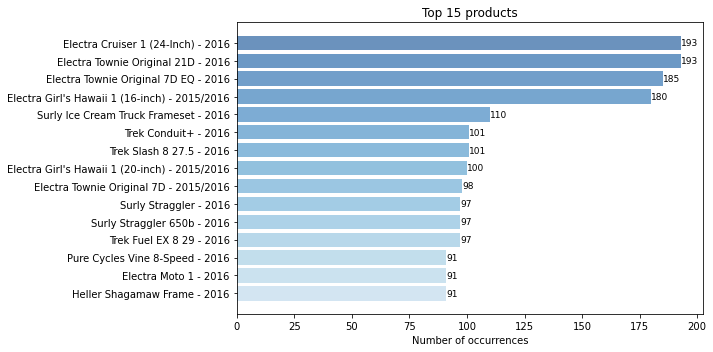

,count,mean,std,min,25%,50%,75%,max
product_name,15.0,121.666667,41.625313,91.0,97.0,100.0,145.0,193.0


In [8]:
top_n = 15
product_name_1 = df['product_name'].value_counts().head(top_n)


colors = plt.cm.Blues(np.linspace(0.9, 0.3, len(product_name_1)))

plt.figure(figsize=(10,5))

bars = plt.barh(
    product_name_1.index,
    product_name_1.values,
    color=colors,
    alpha= 0.6
)

plt.gca().invert_yaxis()  
plt.title('Top 15 products')
plt.xlabel('Number of occurrences')

plt.bar_label(bars, fontsize=9)


plt.tight_layout()
plt.show()

product_name_1_descr = pd.DataFrame(product_name_1.describe())
product_name_1_descr.T

### b. category_name - categorical variables

,count,unique,top,freq
category_name,4722,7,Cruisers Bicycles,1378


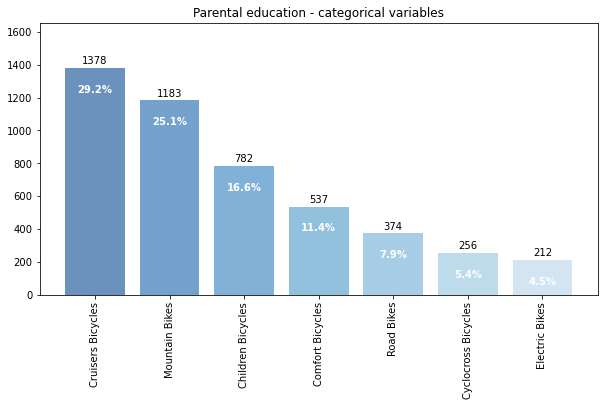

In [9]:
category_name = df['category_name'].dropna()
fdt_category_name_1 = category_name.value_counts()

colors_c = plt.cm.Blues(np.linspace(0.9, 0.3, len(fdt_category_name_1)))
plt.figure(figsize=(10,5))

percentages = fdt_category_name_1 / fdt_category_name_1.sum() * 100

bars = plt.bar(fdt_category_name_1.index,fdt_category_name_1.values, color = colors_c, alpha= 0.6)
plt.ylim(0, max(fdt_category_name_1.values) * 1.2)
plt.bar_label(bars, fontsize=10, padding=2)


for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 150,
        f'{pct:.1f}%',
        ha='center',
        fontsize=10,
        fontweight = 'bold',
        color='white'
    )
    
plt.title('Parental education - categorical variables')
plt.xticks(rotation = 90)

parental_education_descr = pd.DataFrame(category_name.describe())
parental_education_descr.T

### c. list_price - numerical variables

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
list_price,4722.0,1212.707872,1352.798257,89.99,429.0,599.99,1549.0,11999.99,2.12,5.25


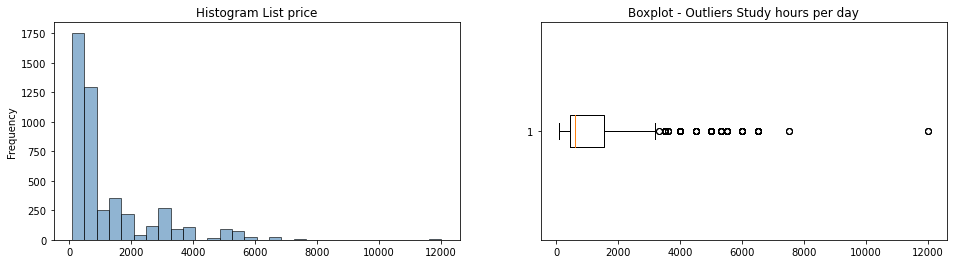

In [11]:
list_price = df['list_price'].dropna()


fig, ax = plt.subplots(1, 2, figsize = (16, 4))

ax[0].hist(list_price, bins=30, density=False, alpha=0.6, edgecolor='black', color = 'steelblue')
ax[0].set_title("Histogram List price")
ax[0].set_ylabel("Frequency")

ax[1].boxplot(df['list_price'], vert=False)
ax[1].set_title("Boxplot - Outliers Study hours per day")


skew_list_price_descr = skew(list_price)
kurt_list_price_descr = kurtosis(list_price)


list_price_descr = pd.DataFrame(list_price.describe())
list_price_descr_descr = list_price_descr.T
list_price_descr_descr["skew"] = round(skew_list_price_descr,2)
list_price_descr_descr["kurtosis"] = round(kurt_list_price_descr,2)
list_price_descr_descr

The analysis of categorical variables was conducted for product_name and category_name. In the case of product_name, the 15 most frequently occurring products were presented out of 278 unique items in the dataset. The analysis of category_name shows that the product assortment is concentrated around seven main product categories. The largest shares are held by Cruisers Bicycles and Mountain Bikes, which together account for more than 50% of all observations.

In the next step, a quantitative analysis of the list_price variable was performed to assess the price structure of the products and to identify potential outliers. The distribution of this variable is clearly right-skewed. The mean value is higher than the median, indicating the presence of high-value outliers and a concentration of prices in the lower and mid-range. The boxplot confirms numerous outliers in the upper price range, while the high kurtosis (5.25) suggests heavy tails in the distribution.

### 4. Analysis of sales distribution across product categories

In [57]:
# H0: Products are sold equally often across all categories.
# H1: Product sales are not equally distributed across categories (at least one category differs in sales frequency).\

category_quantity = df.groupby('category_name')['quantity'].sum()

chi2_stat, p_value = chisquare(category_quantity)

alpha = 0.05

if p_value < alpha:
    print("H0 is rejected. This indicates that product sales are not equally distributed across categories, and at least one category significantly differs in terms of sales frequency.")
else:
    print("There is no evidence to reject the H0. This suggests that product sales are evenly distributed across categories.")

H0 is rejected. This indicates that product sales are not equally distributed across categories, and at least one category significantly differs in terms of sales frequency.


category_name,Cruisers Bicycles,Mountain Bikes,Children Bicycles,Comfort Bicycles,Road Bikes,Cyclocross Bicycles,Electric Bikes
actual,2063.000000,1755.000000,1179.000000,813.000000,559.000000,394.000000,315.000000
mean,1011.142857,1011.142857,1011.142857,1011.142857,1011.142857,1011.142857,1011.142857
difference,1051.857143,743.857143,167.857143,-198.142857,-452.142857,-617.142857,-696.142857


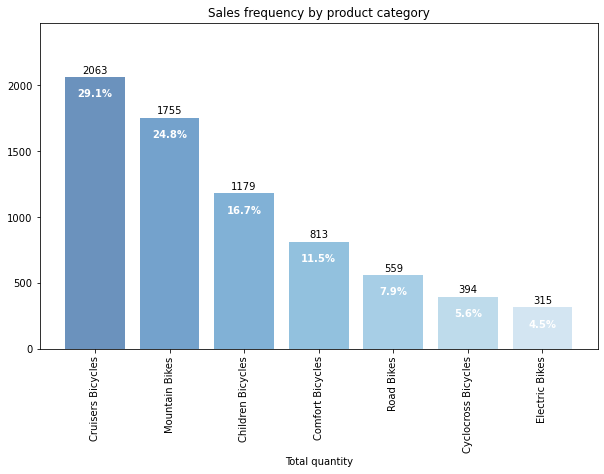

In [56]:
category_quantity = category_quantity.sort_values(ascending = False)
colors_c = plt.cm.Blues(np.linspace(0.9, 0.3, len(category_quantity)))
plt.figure(figsize=(10,6))

percentages = category_quantity / category_quantity.sum() * 100

bars = plt.bar(category_quantity.index,category_quantity.values, color = colors_c, alpha= 0.6)
plt.ylim(0, max(category_quantity.values) * 1.2)
plt.bar_label(bars, fontsize=10, padding=2)
plt.xlabel('Total quantity')


for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 150,
        f'{pct:.1f}%',
        ha='center',
        fontsize=10,
        fontweight = 'bold',
        color='white'
    )
    
plt.title('Sales frequency by product category')
plt.xticks(rotation = 90);


expected = category_quantity.mean()
result = pd.DataFrame({
    'actual': category_quantity,
    'mean': expected,
    'difference': category_quantity - expected
}).sort_values('difference', ascending=False)
result.T

The chi-square test leads to rejection of the null hypothesis at the 5% significance level, indicating that product sales are not evenly distributed across categories.

This result is supported by the bar plot, which clearly shows strong differences between categories. Cruisers Bicycles and Mountain Bikes dominate total sales, while categories such as Electric Bikes and Cyclocross Bikes account for a much smaller share.

Overall, both the statistical test and the visualization confirm a highly uneven distribution of sales across product categories.